In [70]:
# ENV_NAME = "MiniGrid-Empty-16x16-v0"
# OFFLINE_DATASET_VERSION = 5

ENV_NAME = "MiniGrid-LavaGapS5-v0"
OFFLINE_DATASET_VERSION = 0
ENV_SEED = 42

## Train expert policy w/ online RL

In [23]:
import os
import sys

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from rl_zoo3.train import train
from stable_baselines3 import PPO
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import minari
from minari import DataCollector


torch.manual_seed(42)

In [24]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class MinigridFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.Space, features_dim: int = 512,
                 normalized_image: bool = False) -> None:
        super().__init__(observation_space, features_dim)
        n_input_channels = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 16, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(16, 32, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, (2, 2)),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            obs_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(obs_tensor).shape[1]
        
        self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.ReLU())
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(self.cnn(x))

In [16]:
# TRAIN EXPERT POLICY

import minigrid
from minigrid.wrappers import ImgObsWrapper

policy_kwargs = dict(
    features_extractor_class=MinigridFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=128)
)

env = gym.make(ENV_NAME)
env = ImgObsWrapper(env)

model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1)
model.learn(2e5)

# Save current model as best model
model.save(f"./logs/ppo/{ENV_NAME}/best_model")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 36.2     |
|    ep_rew_mean     | 0.0515   |
| time/              |          |
|    fps             | 2239     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 42.2        |
|    ep_rew_mean          | 0.0346      |
| time/                   |             |
|    fps                  | 963         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013608549 |
|    clip_fraction        | 0.103       |
|    clip_range      

/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'logs/ppo/MiniGrid-LavaGapS5-v0' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


In [38]:
from gymnasium.utils import RecordConstructorArgs
from minigrid.wrappers import ImgObsWrapper as MGImgObsWrapper

class RecordedImgObsWrapper(MGImgObsWrapper, RecordConstructorArgs):
    def __init__(self, env):
        RecordConstructorArgs.__init__(self)
        super().__init__(env)

env = DataCollector(RecordedImgObsWrapper(gym.make(ENV_NAME)), data_format="parquet")
path = os.path.abspath('') + f'/logs/ppo/{ENV_NAME}/best_model'
agent = PPO.load(path)

total_episodes = 1_000
# total_episodes = 1

for _ in tqdm(range(total_episodes)):
    obs, _ = env.reset()
    terminated = False
    truncated = False
    while not (terminated or truncated):
        action, _ = agent.predict(obs, deterministic=True)
        obs, rew, terminated, truncated, info = env.step(action)

100%|██████████| 1000/1000 [00:50<00:00, 19.87it/s]


In [39]:
dataset_name = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
dataset = env.create_dataset(
    dataset_id=dataset_name,
    algorithm_name="ExpertPolicy",
    code_permalink="https://minari.farama.org/tutorials/behavioral_cloning",
    author="Farama",
    author_email="contact@farama.org",
)

print(f"Collected dataset:\n{dataset_name}")

/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/minari/utils.py:269: UserWarning: `description` is set to None. For longevity purposes it is highly recommended to provide a description of the dataset
  warnings.warn(
/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/minari/utils.py:284: UserWarning: `eval_env` is set to None. If another environment is intended to be used for evaluation please specify corresponding Gymnasium environment (gym.Env | gym.envs.registration.EnvSpec). If None the environment used to collect the data (`env=EnvSpec(id='MiniGrid-LavaGapS5-v0', entry_point='minigrid.envs:LavaGapEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 5}, namespace=None, name='MiniGrid-LavaGapS5', version=0, additional_wrappers=(WrapperSpec(name='RecordedImgObsWrapper', entry_point='__main__:RecordedImgObsWrapper', kwargs={}),), vector_entry_po

Collected dataset:
MiniGrid-LavaGapS5-v0/expert-v0


In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNetwork(nn.Module):
    def __init__(self, observation_space, output_dim):
        super().__init__()

        obs_shape = observation_space.shape
        input_channels = obs_shape[2] if len(obs_shape) == 3 else 1

        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 16, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(16, 32, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, (2, 2)),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            sample_obs = observation_space.sample()
            sample_obs = torch.from_numpy(sample_obs).permute(2, 0, 1).unsqueeze(0).float() if len(obs_shape) == 3 else torch.from_numpy(sample_obs).unsqueeze(0).unsqueeze(0).float()
            n_flatten = self.cnn(sample_obs).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, 512),
            nn.ReLU()
        )
        self.head = nn.Linear(512, output_dim)

    def forward(self, x):
        # Expect either (B,H,W,C) or (H,W,C)
        if x.dim() == 3:
            x = x.permute(2, 0, 1).unsqueeze(0)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)
        else:
            raise NotImplementedError(f"Expected 3 or 4 dimensions, got {x.dim()}")
        features = self.linear(self.cnn(x.float()))
        logits = self.head(features)
        return logits

In [41]:
def collate_fn(batch):
    """
    Flatten a batch of episodes into a batch of transitions.

    Assumes ep.observations is already an array of shape (T_obs, H, W, C)
    (as returned by the Arrow/Parquet Minari loaders), and uses only the
    first T steps matching len(ep.actions).
    """
    obs_list = []
    action_list = []
    reward_list = []
    termination_list = []
    truncation_list = []
    id_list = []

    for ep in batch:
        # ep.observations: (T_obs, H, W, C)
        frames = np.asarray(ep.observations, dtype=np.float32)
        if frames.ndim == 3:  # just in case a single frame episode appears
            frames = frames[None, ...]

        T = len(ep.actions)
        obs_list.append(torch.from_numpy(frames[:T]))          # (T, H, W, C)
        action_list.append(torch.as_tensor(ep.actions))
        reward_list.append(torch.as_tensor(ep.rewards))
        termination_list.append(torch.as_tensor(ep.terminations))
        truncation_list.append(torch.as_tensor(ep.truncations))
        id_list.append(torch.full((T,), ep.id))

    observations = torch.cat(obs_list, dim=0)          # (N, H, W, C)
    actions = torch.cat(action_list, dim=0)            # (N,)
    rewards = torch.cat(reward_list, dim=0)            # (N,)
    terminations = torch.cat(termination_list, dim=0)  # (N,)
    truncations = torch.cat(truncation_list, dim=0)    # (N,)
    ids = torch.cat(id_list, dim=0)                    # (N,)

    return {
        "id": ids,
        "observations": observations,
        "actions": actions,
        "rewards": rewards,
        "terminations": terminations,
        "truncations": truncations,
    }

In [45]:
ep = minari_dataset[0]

print(f"Type: {type(ep)}")
if hasattr(ep, "__dict__"):
    for field, value in ep.__dict__.items():
        print(f"\nField: {field}")
        print(f"  Type: {type(value)}")
        if isinstance(value, np.ndarray):
            print(f"  Shape: {value.shape}")
            print(f"  Dtype: {value.dtype}")
            # For object arrays, try to infer inner shapes/dtypes
            if value.dtype == object:
                try:
                    inner_shapes = [None if v is None else np.shape(v) for v in value]
                    inner_dtypes = [None if v is None else np.array(v).dtype for v in value]
                    print(f"  Inner shapes: {inner_shapes}")
                    print(f"  Inner dtypes: {inner_dtypes}")
                except Exception as e:
                    print(f"  Could not infer inner shapes/dtypes: {e}")
        elif isinstance(value, list):
            print(f"  Length: {len(value)}")
            print(f"  Example type: {type(value[0]) if value else 'N/A'}")
            try:
                inner_shapes = [np.shape(x) for x in value]
                inner_dtypes = [np.array(x).dtype for x in value]
                print(f"  Inner shapes: {inner_shapes}")
                print(f"  Inner dtypes: {inner_dtypes}")
            except Exception:
                pass
        else:
            print(f"  Value preview: {str(value)[:60]}")
else:
    print(ep)

Type: <class 'minari.dataset.episode_data.EpisodeData'>

Field: id
  Type: <class 'numpy.int64'>
  Value preview: 0

Field: observations
  Type: <class 'numpy.ndarray'>
  Shape: (6, 7, 7, 3)
  Dtype: uint8

Field: actions
  Type: <class 'numpy.ndarray'>
  Shape: (5,)
  Dtype: int64

Field: rewards
  Type: <class 'numpy.ndarray'>
  Shape: (5,)
  Dtype: float64

Field: terminations
  Type: <class 'numpy.ndarray'>
  Shape: (5,)
  Dtype: bool

Field: truncations
  Type: <class 'numpy.ndarray'>
  Shape: (5,)
  Dtype: bool

Field: infos
  Type: <class 'dict'>
  Value preview: {}


In [ ]:
# Train

import datetime

DATASET_NAME = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
NUM_EPOCHS = 12
EVAL_EVERY_N_EPOCHS = 2

now = datetime.datetime.now()

minari_dataset = minari.load_dataset(DATASET_NAME)
dataloader = DataLoader(minari_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)

env = minari_dataset.recover_environment()
observation_space = env.observation_space
action_space = env.action_space
assert isinstance(observation_space, spaces.Box)
assert isinstance(action_space, spaces.Discrete)

policy_net = PolicyNetwork(observation_space, action_space.n)
optimizer = torch.optim.Adam(policy_net.parameters())
loss_fn = nn.CrossEntropyLoss()

# Set up eval environment for periodic testing
eval_env = minari_dataset.recover_environment(render_mode="rgb_array")

for epoch in range(NUM_EPOCHS):
    for batch in dataloader:
        a_pred = policy_net(batch['observations'])
        a_hat = batch["actions"].type(torch.int64)
        loss = loss_fn(a_pred, a_hat)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch}/{NUM_EPOCHS}, Loss: {loss.item():.3f}")

    # Periodic evaluation
    if (epoch + 1) % EVAL_EVERY_N_EPOCHS == 0:
        obs, _ = eval_env.reset(seed=ENV_SEED)
        terminated, truncated = False, False
        accumulated_rew = 0
        while not (terminated or truncated):
            with torch.no_grad():
                action = policy_net(torch.Tensor(obs)).argmax().item()
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            accumulated_rew += reward
        print(f"Eval after epoch {epoch+1}: reward = {accumulated_rew}")


Epoch: 0/12, Loss: 1.069
Epoch: 1/12, Loss: 0.681
Eval after epoch 2: reward = 0.955
Epoch: 2/12, Loss: 0.441
Epoch: 3/12, Loss: 0.310
Eval after epoch 4: reward = 0.955
Epoch: 4/12, Loss: 0.188
Epoch: 5/12, Loss: 0.105
Eval after epoch 6: reward = 0.955
Epoch: 6/12, Loss: 0.047
Epoch: 7/12, Loss: 0.026
Eval after epoch 8: reward = 0.955
Epoch: 8/12, Loss: 0.013
Epoch: 9/12, Loss: 0.005
Eval after epoch 10: reward = 0.955
Epoch: 10/12, Loss: 0.003
Epoch: 11/12, Loss: 0.002
Eval after epoch 12: reward = 0.955


In [ ]:
# Evaluate trained model

import os
import imageio

# Set up directories and video saving vars
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%H%M%S")
base_dir = f"videos/offline/bc/{DATASET_NAME}/{date_str}_{time_str}"
os.makedirs(base_dir, exist_ok=True)

final_path = os.path.join(
    base_dir,
    f"epoch={epoch+1}_reward={{}}.mp4"
)

# Use the evaluation environment recovered from the offline dataset
env = minari_dataset.recover_environment(render_mode="rgb_array")

frames = []
obs, _ = env.reset(seed=ENV_SEED)
terminated, truncated = False, False
accumulated_rew = 0
while not (terminated or truncated):
    frame = env.render()
    frames.append(frame)
    obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        action = policy_net(obs_tensor).argmax(dim=-1).item()
    obs, reward, terminated, truncated, _ = env.step(action)
    accumulated_rew += reward

env.close()

final_path = os.path.join(
    base_dir,
    f"epoch={epoch+1}_reward={rew:.3f}.mp4"
)
imageio.mimsave(final_path, frames, fps=30)

print("Accumulated rew: ", accumulated_rew)
print(f"Video saved to:\n{final_path}")

Accumulated rew:  0.955
Video saved to:
videos/offline/bc/MiniGrid-LavaGapS5-v0/expert-v0/2025-12-02_141626/epoch=12_reward=0.937.mp4


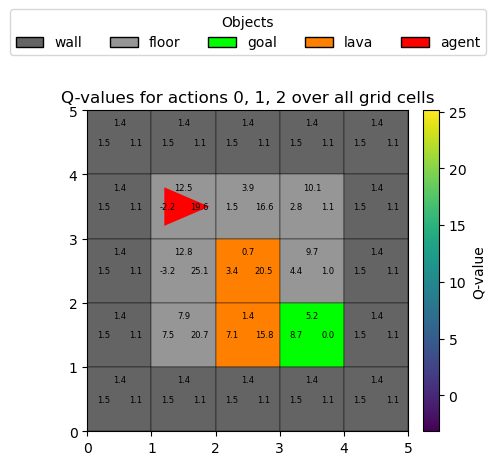

In [ ]:
# VISUALIZE Q-VALUES
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Patch
import numpy as np
import re

from minigrid.core.constants import OBJECT_TO_IDX

IDX_TO_OBJECT = {v: k for k, v in OBJECT_TO_IDX.items()}

OBJECT_TO_COLOR = {
    "unseen": np.array([0, 0, 0]) / 255.0,
    "empty":  np.array([40, 40, 40]) / 255.0,
    "wall":   np.array([100, 100, 100]) / 255.0,
    "floor":  np.array([150, 150, 150]) / 255.0,
    "door":   np.array([180, 130, 80]) / 255.0,
    "key":    np.array([0, 170, 255]) / 255.0,
    "ball":   np.array([255, 170, 0]) / 255.0,
    "box":    np.array([150, 90, 40]) / 255.0,
    "goal":   np.array([0, 255, 0]) / 255.0,
    "lava":   np.array([255, 128, 0]) / 255.0,
    "agent":  np.array([255, 0, 0]) / 255.0,
}

# configure overlay strength outside if you like, e.g. OVERLAY_ALPHA = 0.3

OVERLAY_ALPHA = 0.0

env = minari_dataset.recover_environment(render_mode=None)
obs, _ = env.reset(seed=ENV_SEED)

wrappers = []
cur = env
while hasattr(cur, "env"):
    wrappers.append(cur)
    cur = cur.env
base_env = cur
wrappers_from_base = wrappers[::-1]

orig_pos = np.array(base_env.agent_pos)
orig_dir = int(base_env.agent_dir)  # 0:right, 1:down, 2:left, 3:up
gap_x, gap_y = map(int, base_env.gap_pos)
goal_x, goal_y = map(int, base_env.goal_pos)
agent_x, agent_y = map(int, base_env.agent_pos)

example_q = policy_net(torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0))
n_actions = example_q.shape[-1]

grid_w = base_env.grid.width
grid_h = base_env.grid.height

m = re.search(r"S(\d+)", ENV_NAME)
if m:
    grid_size = int(m.group(1))
else:
    grid_size = grid_w

q_grid = np.zeros((grid_h, grid_w, n_actions), dtype=np.float32)

for y in range(grid_h):
    for x in range(grid_w):
        base_env.agent_pos = np.array((x, y))
        base_env.agent_dir = orig_dir

        base_obs = base_env.gen_obs()
        obs_wrapped = base_obs
        for w in wrappers_from_base:
            if hasattr(w, "observation"):
                obs_wrapped = w.observation(obs_wrapped)

        obs_tensor = torch.as_tensor(obs_wrapped, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = policy_net(obs_tensor).cpu().numpy().squeeze()
        q_grid[y, x, :] = q_values

base_env.agent_pos = orig_pos
base_env.agent_dir = orig_dir

fig, ax = plt.subplots(figsize=(grid_size, grid_size))

# 1) Background from LavaGap layout (walls, lava, goal, floor)
for y in range(grid_h):
    for x in range(grid_w):
        if x == 0 or x == grid_w - 1 or y == 0 or y == grid_h - 1:
            obj_name = "wall"
        elif (x, y) == (goal_x, goal_y):
            obj_name = "goal"
        elif x == gap_x and 1 <= y <= grid_h - 2 and (x, y) != (gap_x, gap_y):
            obj_name = "lava"
        else:
            obj_name = "floor"

        bg = OBJECT_TO_COLOR[obj_name]
        cx, cy = x, grid_h - y - 1
        ax.add_patch(
            Rectangle((cx, cy), 1, 1, facecolor=bg, edgecolor="k", linewidth=0.3)
        )

# 2) Agent triangle on top of its floor cell, oriented by orig_dir
ax_cx, ax_cy = agent_x, grid_h - agent_y - 1
if orig_dir == 0:  # right
    agent_tri = [
        (ax_cx + 0.2, ax_cy + 0.2),
        (ax_cx + 0.2, ax_cy + 0.8),
        (ax_cx + 0.9, ax_cy + 0.5),
    ]
elif orig_dir == 1:  # down
    agent_tri = [
        (ax_cx + 0.2, ax_cy + 0.8),
        (ax_cx + 0.8, ax_cy + 0.8),
        (ax_cx + 0.5, ax_cy + 0.1),
    ]
elif orig_dir == 2:  # left
    agent_tri = [
        (ax_cx + 0.8, ax_cy + 0.2),
        (ax_cx + 0.8, ax_cy + 0.8),
        (ax_cx + 0.1, ax_cy + 0.5),
    ]
else:  # orig_dir == 3, up
    agent_tri = [
        (ax_cx + 0.2, ax_cy + 0.2),
        (ax_cx + 0.8, ax_cy + 0.2),
        (ax_cx + 0.5, ax_cy + 0.9),
    ]

ax.add_patch(Polygon(agent_tri, facecolor=OBJECT_TO_COLOR["agent"], edgecolor="none"))

# 3) Q-value overlay as triangles with numbers
actions_to_visualize = [0, 1, 2]

vmin = float(q_grid[:, :, actions_to_visualize].min())
vmax = float(q_grid[:, :, actions_to_visualize].max())
norm = plt.Normalize(vmin, vmax)
cmap = plt.cm.viridis

for y in range(grid_h):
    for x in range(grid_w):
        cx, cy = x, grid_h - y - 1

        corners = [
            (cx, cy),
            (cx + 1, cy),
            (cx + 1, cy + 1),
            (cx, cy + 1),
        ]
        center = (cx + 0.5, cy + 0.5)
        triangles = [
            [corners[0], corners[3], center],  # left
            [corners[3], corners[2], center],  # top
            [corners[2], corners[1], center],  # right
        ]
        text_positions = [
            (cx + 0.25, cy + 0.5),
            (cx + 0.5,  cy + 0.8),
            (cx + 0.75, cy + 0.5),
        ]

        q_cell = q_grid[y, x]
        for i, act in enumerate(actions_to_visualize):
            qv = float(q_cell[act])
            color = cmap(norm(qv))
            poly = Polygon(triangles[i], color=color, alpha=OVERLAY_ALPHA)
            ax.add_patch(poly)

            ax.text(
                text_positions[i][0],
                text_positions[i][1],
                f"{qv:.1f}",
                ha="center",
                va="center",
                fontsize=6,
                color="black",
            )

ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_xticks(np.arange(grid_size + 1))
ax.set_yticks(np.arange(grid_size + 1))
ax.set_aspect("equal")

# Q-value colorbar on the right
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, label="Q-value", fraction=0.046, pad=0.04)

# Object color legend ABOVE the plot (no overlap with colorbar)
legend_handles = [
    Patch(facecolor=OBJECT_TO_COLOR["wall"],  edgecolor="k", label="wall"),
    Patch(facecolor=OBJECT_TO_COLOR["floor"], edgecolor="k", label="floor"),
    Patch(facecolor=OBJECT_TO_COLOR["goal"],  edgecolor="k", label="goal"),
    Patch(facecolor=OBJECT_TO_COLOR["lava"],  edgecolor="k", label="lava"),
    Patch(facecolor=OBJECT_TO_COLOR["agent"], edgecolor="k", label="agent"),
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(legend_handles),
    title="Objects",
)

plt.title("Q-values for actions 0, 1, 2 over all grid cells")
plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave room at top for legend
plt.show()

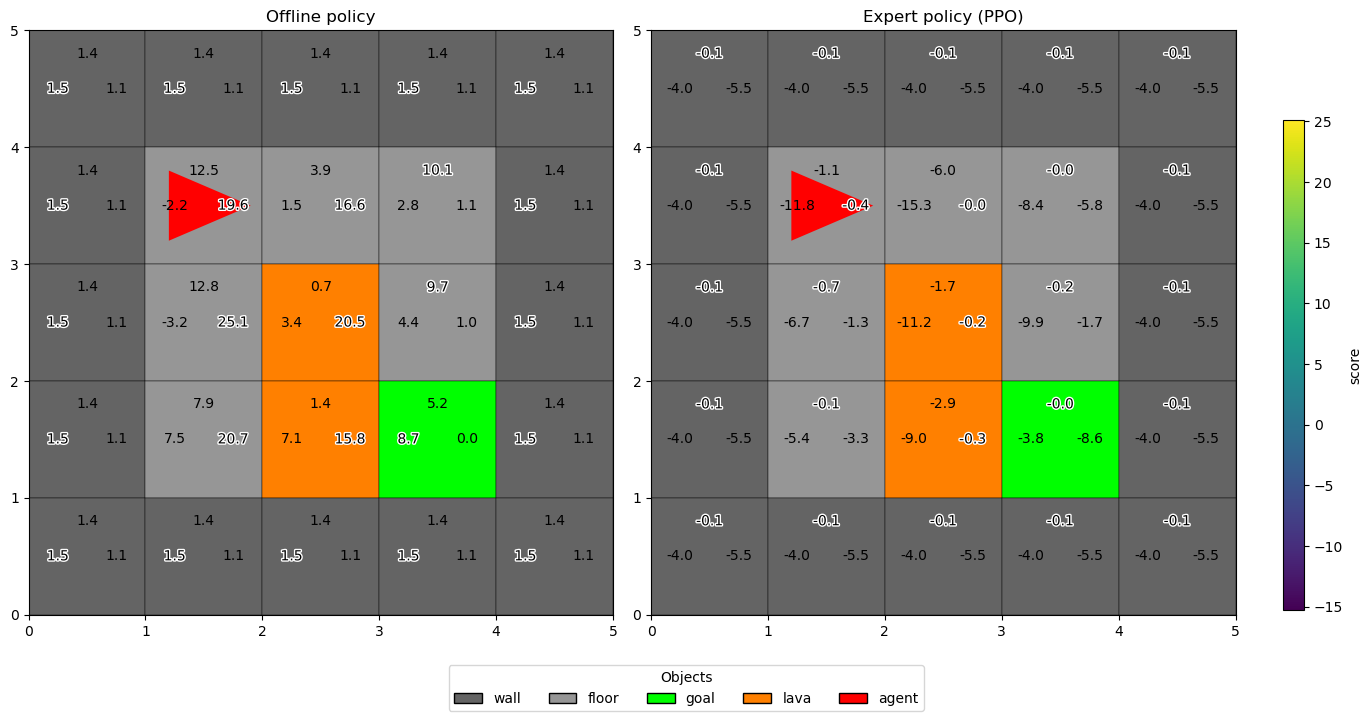

In [82]:
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.patches import Rectangle, Polygon, Patch
import numpy as np
import re

from minigrid.core.constants import OBJECT_TO_IDX

IDX_TO_OBJECT = {v: k for k, v in OBJECT_TO_IDX.items()}

OBJECT_TO_COLOR = {
    "unseen": np.array([0, 0, 0]) / 255.0,
    "empty":  np.array([40, 40, 40]) / 255.0,
    "wall":   np.array([100, 100, 100]) / 255.0,
    "floor":  np.array([150, 150, 150]) / 255.0,
    "door":   np.array([180, 130, 80]) / 255.0,
    "key":    np.array([0, 170, 255]) / 255.0,
    "ball":   np.array([255, 170, 0]) / 255.0,
    "box":    np.array([150, 90, 40]) / 255.0,
    "goal":   np.array([0, 255, 0]) / 255.0,
    "lava":   np.array([255, 128, 0]) / 255.0,
    "agent":  np.array([255, 0, 0]) / 255.0,
}

ACTIONS_TO_VISUALIZE = [0, 1, 2]  # left / forward / right (interpreted scores)
OVERLAY_ALPHA = OVERLAY_ALPHA  # use value set earlier, e.g. 0.3

env = minari_dataset.recover_environment(render_mode=None)
obs, _ = env.reset(seed=ENV_SEED)

# unwrap to base MiniGrid env
wrappers = []
cur = env
while hasattr(cur, "env"):
    wrappers.append(cur)
    cur = cur.env
base_env = cur
wrappers_from_base = wrappers[::-1]

orig_pos = np.array(base_env.agent_pos)
orig_dir = int(base_env.agent_dir)
gap_x, gap_y = map(int, base_env.gap_pos)
goal_x, goal_y = map(int, base_env.goal_pos)
agent_x, agent_y = map(int, base_env.agent_pos)

grid_w = base_env.grid.width
grid_h = base_env.grid.height

m = re.search(r"S(\d+)", ENV_NAME)
if m:
    grid_size = int(m.group(1))
else:
    grid_size = grid_w

def wrapped_obs_at(x, y):
    base_env.agent_pos = np.array((x, y))
    base_env.agent_dir = orig_dir
    base_obs = base_env.gen_obs()
    obs_wrapped = base_obs
    for w in wrappers_from_base:
        if hasattr(w, "observation"):
            obs_wrapped = w.observation(obs_wrapped)
    return obs_wrapped

def score_grid_from_policy(score_fn, n_actions):
    grid = np.zeros((grid_h, grid_w, n_actions), dtype=np.float32)
    for y in range(grid_h):
        for x in range(grid_w):
            obs_wrapped = wrapped_obs_at(x, y)
            grid[y, x, :] = score_fn(obs_wrapped)
    return grid

def bc_scores(obs_wrapped):
    obs_tensor = torch.as_tensor(obs_wrapped, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q = policy_net(obs_tensor)
    return q.cpu().numpy().squeeze()

def expert_scores(obs_wrapped):
    # extract image
    if isinstance(obs_wrapped, dict):
        img = obs_wrapped["image"]
    else:
        img = obs_wrapped

    img = np.asarray(img)

    # convert HWC -> CHW for SB3 CNN policy
    if img.ndim == 3:
        img = np.transpose(img, (2, 0, 1))  # (H, W, C) -> (C, H, W)
    elif img.ndim == 2:
        img = img[None, ...]  # (H, W) -> (1, H, W)

    obs_tensor = torch.as_tensor(img, dtype=torch.float32).unsqueeze(0).to(agent.device)

    with torch.no_grad():
        dist = agent.policy.get_distribution(obs_tensor)
        logits = dist.distribution.logits

    return logits.detach().cpu().numpy().squeeze()
# infer number of actions from offline policy
example_q = bc_scores(obs)
n_actions = example_q.shape[-1]

q_offline = score_grid_from_policy(bc_scores, n_actions)
q_expert = score_grid_from_policy(expert_scores, n_actions)

# restore env state
base_env.agent_pos = orig_pos
base_env.agent_dir = orig_dir

def cell_object_name(x, y):
    if x == 0 or x == grid_w - 1 or y == 0 or y == grid_h - 1:
        return "wall"
    if (x, y) == (goal_x, goal_y):
        return "goal"
    if x == gap_x and 1 <= y <= grid_h - 2 and (x, y) != (gap_x, gap_y):
        return "lava"
    return "floor"

def draw_single(ax, score_grid, cmap, norm, title):
    for y in range(grid_h):
        for x in range(grid_w):
            obj_name = cell_object_name(x, y)
            bg = OBJECT_TO_COLOR[obj_name]
            cx, cy = x, grid_h - y - 1
            ax.add_patch(
                Rectangle((cx, cy), 1, 1, facecolor=bg, edgecolor="k", linewidth=0.3)
            )

    # agent triangle
    ax_cx, ax_cy = agent_x, grid_h - agent_y - 1
    if orig_dir == 0:
        agent_tri = [(ax_cx + 0.2, ax_cy + 0.2),
                     (ax_cx + 0.2, ax_cy + 0.8),
                     (ax_cx + 0.9, ax_cy + 0.5)]
    elif orig_dir == 1:
        agent_tri = [(ax_cx + 0.2, ax_cy + 0.8),
                     (ax_cx + 0.8, ax_cy + 0.8),
                     (ax_cx + 0.5, ax_cy + 0.1)]
    elif orig_dir == 2:
        agent_tri = [(ax_cx + 0.8, ax_cy + 0.2),
                     (ax_cx + 0.8, ax_cy + 0.8),
                     (ax_cx + 0.1, ax_cy + 0.5)]
    else:
        agent_tri = [(ax_cx + 0.2, ax_cy + 0.2),
                     (ax_cx + 0.8, ax_cy + 0.2),
                     (ax_cx + 0.5, ax_cy + 0.9)]
    ax.add_patch(Polygon(agent_tri, facecolor=OBJECT_TO_COLOR["agent"], edgecolor="none"))

    for y in range(grid_h):
        for x in range(grid_w):
            cx, cy = x, grid_h - y - 1
            corners = [(cx, cy), (cx + 1, cy), (cx + 1, cy + 1), (cx, cy + 1)]
            center = (cx + 0.5, cy + 0.5)
            triangles = [
                [corners[0], corners[3], center],  # left
                [corners[3], corners[2], center],  # top
                [corners[2], corners[1], center],  # right
            ]
            text_positions = [
                (cx + 0.25, cy + 0.5),
                (cx + 0.5,  cy + 0.8),
                (cx + 0.75, cy + 0.5),
            ]

            q_cell = score_grid[y, x]
            vals = [float(q_cell[a]) for a in ACTIONS_TO_VISUALIZE]
            best_i = int(np.argmax(vals))

            for i, act in enumerate(ACTIONS_TO_VISUALIZE):
                val = vals[i]
                color = cmap(norm(val))
                ax.add_patch(Polygon(triangles[i], color=color, alpha=OVERLAY_ALPHA))

                txt = ax.text(
                    text_positions[i][0],
                    text_positions[i][1],
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="black",
                )

                if i == best_i:
                    txt.set_path_effects(
                        [pe.withStroke(linewidth=2, foreground="white")]
                    )

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_xticks(np.arange(grid_size + 1))
    ax.set_yticks(np.arange(grid_size + 1))
    ax.set_aspect("equal")
    ax.set_title(title)

vmin = float(
    min(
        q_offline[:, :, ACTIONS_TO_VISUALIZE].min(),
        q_expert[:, :, ACTIONS_TO_VISUALIZE].min(),
    )
)
vmax = float(
    max(
        q_offline[:, :, ACTIONS_TO_VISUALIZE].max(),
        q_expert[:, :, ACTIONS_TO_VISUALIZE].max(),
    )
)
cmap = plt.cm.viridis
norm = plt.Normalize(vmin, vmax)

fig, axes = plt.subplots(1, 2, figsize=(2 * grid_size + 4, grid_size + 2))

draw_single(axes[0], q_offline, cmap, norm, "Offline policy")
draw_single(axes[1], q_expert, cmap, norm, "Expert policy (PPO)")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

# reserve some space on the right for the colorbar
plt.tight_layout(rect=[0, 0.12, 0.9, 1])

# dedicated axis for colorbar to the right of both grids
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height] in figure coords
fig.colorbar(sm, cax=cax, label="score")

legend_handles = [
    Patch(facecolor=OBJECT_TO_COLOR["wall"],  edgecolor="k", label="wall"),
    Patch(facecolor=OBJECT_TO_COLOR["floor"], edgecolor="k", label="floor"),
    Patch(facecolor=OBJECT_TO_COLOR["goal"],  edgecolor="k", label="goal"),
    Patch(facecolor=OBJECT_TO_COLOR["lava"],  edgecolor="k", label="lava"),
    Patch(facecolor=OBJECT_TO_COLOR["agent"], edgecolor="k", label="agent"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    title="Objects",
)

plt.show()